#Import Libraries

In [19]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

#Load Dataset

In [20]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

#Checking the Dataset Shape

In [21]:
print("Training Images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Testing Images:", test_images.shape)
print("Testing Labels:", test_labels.shape)


Training Images: (60000, 28, 28)
Training labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


#Displaying the images

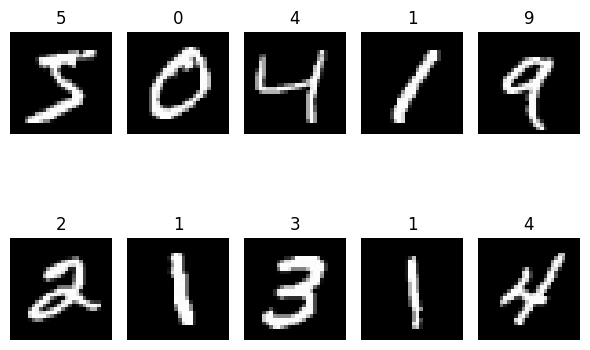

In [22]:
plt.figure(figsize=(6,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(train_images[i], cmap = 'gray')
  plt.title(train_labels[i])
  plt.axis('off')
plt.tight_layout()
plt.show()

#Normalization

In [23]:
train_images = train_images/255.0
test_images = test_images/255.0

#Reshaping the images

In [24]:
train_images = train_images.reshape((60000,28,28,1))
test_images = test_images.reshape((10000,28,28,1))

In [25]:
print(train_images.shape)

(60000, 28, 28, 1)


#Data Augmentation

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10, zoom_range = 0.1, width_shift_range=0.1, height_shift_range = 0.1 )
datagen.fit(train_images)

#Building The CNN Model

In [27]:
model = models.Sequential([layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(64, (3,3), activation = 'relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(64, activation = 'relu'),
                           layers.Dropout(0.5),
                           layers.Dense(10, activation = 'softmax')])

#Model Summary

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

#Compiling the Model

In [29]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

#Model Training

In [30]:
history = model.fit(datagen.flow(train_images, train_labels, batch_size = 32), epochs = 5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.8246 - loss: 0.5458 - val_accuracy: 0.9830 - val_loss: 0.0542
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9243 - loss: 0.2529 - val_accuracy: 0.9865 - val_loss: 0.0409
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 108s 58ms/step - accuracy: 0.9432 - loss: 0.1901 - val_accuracy: 0.9897 - val_loss: 0.0304
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 116s 62ms/step - accuracy: 0.9533 - loss: 0.1577 - val_accuracy: 0.9900 - val_loss: 0.0283
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 99s 53ms/step - accuracy: 0.9596 - loss: 0.1370 - val_accuracy: 0.9907 - val_loss: 0.0269


#Evaluating the Model

In [31]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9907 - loss: 0.0269
Test Accuracy: 0.9907000064849854


#GRAPH 1(Accuracy Graph)

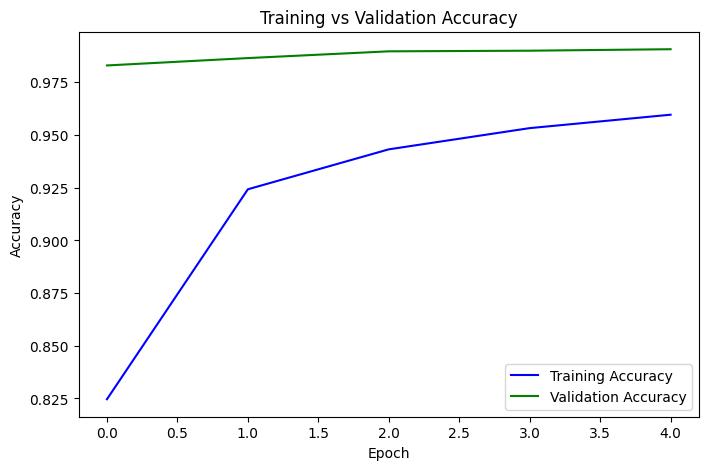

In [32]:
plt.figure(figsize = (8,5))
plt.plot(history.history['accuracy'], label = "Training Accuracy", color= 'blue')
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy", color = 'green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")
plt.show()

#GRAPH 2(Loss Graph)

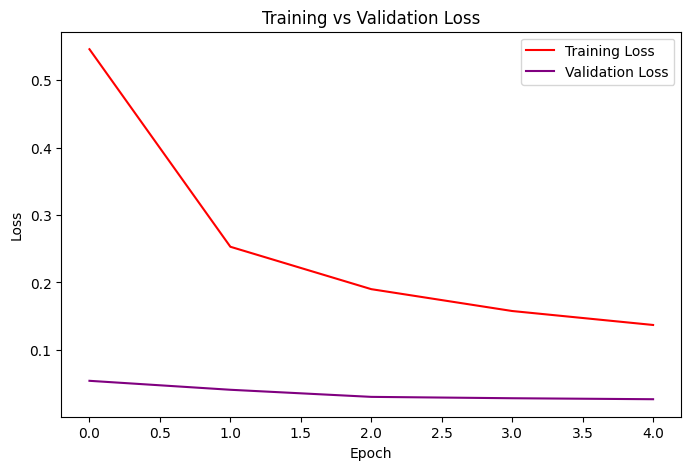

In [33]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label = 'Training Loss', color = 'red')
plt.plot(history.history['val_loss'], label = 'Validation Loss', color = 'purple')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("loss_plot.png")
plt.show()

#Predicting the sample images

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


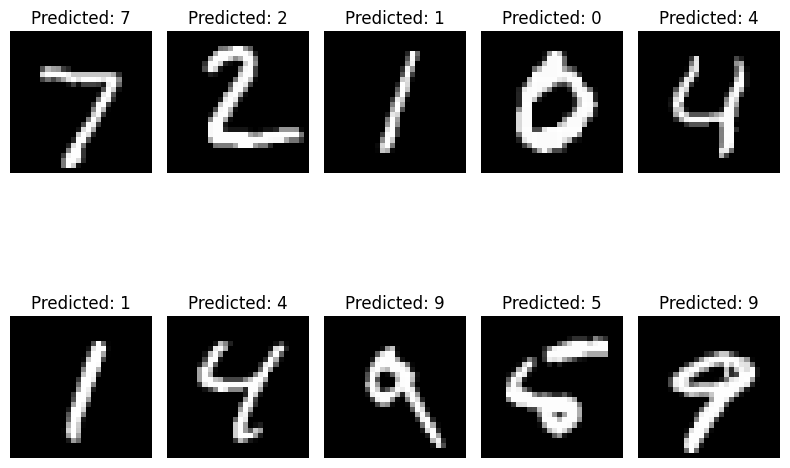

In [34]:
predictions = model.predict(test_images)
plt.figure(figsize = (8,7))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(test_images[i].reshape(28,28), cmap = 'gray')
  plt.title(f"Predicted: {np.argmax(predictions[i])}")
  plt.axis('off')
plt.tight_layout()
plt.savefig("Prediction.png")
plt.show()

#Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


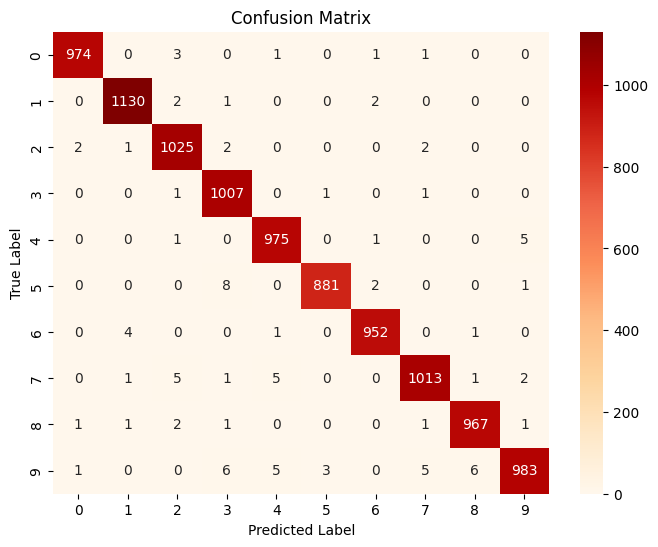

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
predictions = model.predict(test_images)
predicted_labels = predictions.argmax(axis=1)
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='OrRd',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

#Classification Report

In [42]:
from sklearn.metrics import classification_report
print(classification_report(test_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



#Saving the Model

In [35]:
model.save("cnn_mnist_model.h5")